# Notebook for work on development of un-spot-able

## Setting up needed imports & data

### Imports from create_eigens

In [1]:
#General imports
import os
import sys
import numpy as np
import faulthandler
faulthandler.enable()

# Directory structure
from pathlib import Path
maindir = str(Path(os.getcwd()).parent)
libdir  = os.path.join(maindir, 'lib')
if not libdir in sys.path:
    sys.path.append(maindir)
    sys.path.append(libdir)

from lib import eigen
from lib import utils
from lib import fitclass as fc
from lib.spotable import spotable as se


import starry2 as starry
# Set up starry configuration
starry.config.quiet = True
starry.config.lazy = True
sys.setrecursionlimit(10000) # starry seems to have a lot of recursion


# Whether or not to show print statements in code
dpm = True #change to False to make quiet

### Additional imports from create_emaps

In [2]:
#General imports 
from cmcrameri import cm
import matplotlib as mpl
mpl.rcParams['axes.formatter.useoffset'] = False
import matplotlib.path as mpath
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

#lib imports
from lib import lat_lon_lines

### Additional imports from create_rv & create_real_null

In [3]:
#General imports
try:
    plt.rcParams['animation.convert_path'] = '/opt/homebrew/bin/magick'
    pass
except:
    pass

import matplotlib.animation as animation
from IPython.display import HTML

### Importing each .py file

In [4]:
import create_eigens
import create_emaps
import create_rv
import create_real_null

### Reading Config File

In [5]:
fit = fc.Fit()
fit.read_config("../eridani.cfg")

cfg = fit.cfg

lmax = cfg.sim.lmax
udeg = cfg.star.udeg

### Python magic commands for better notebook displays

In [6]:
%matplotlib inline

## Testing Plotting Functionality - June 23rd

In [7]:
base_eigens = np.loadtxt("../eridani-outputs/results-70i/stored-eigens/eigeny.txt")
norm_eigens = np.loadtxt("../eridani-outputs/results-70i/stored-norm-null-eigens/norm_null_eigeny.txt")

s1 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
s2 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)

In [8]:
s1.map[:,:] = base_eigens[10]
s2.map[:,:] = norm_eigens[10]

In [9]:
# s1.map.show(rv=True,theta=np.linspace(0,360,91),dpi=100,colorbar=True)

In [10]:
# s1.map.show(rv=True,theta=np.linspace(0,360,91),dpi=100,colorbar=True, cmap=cm.vik)

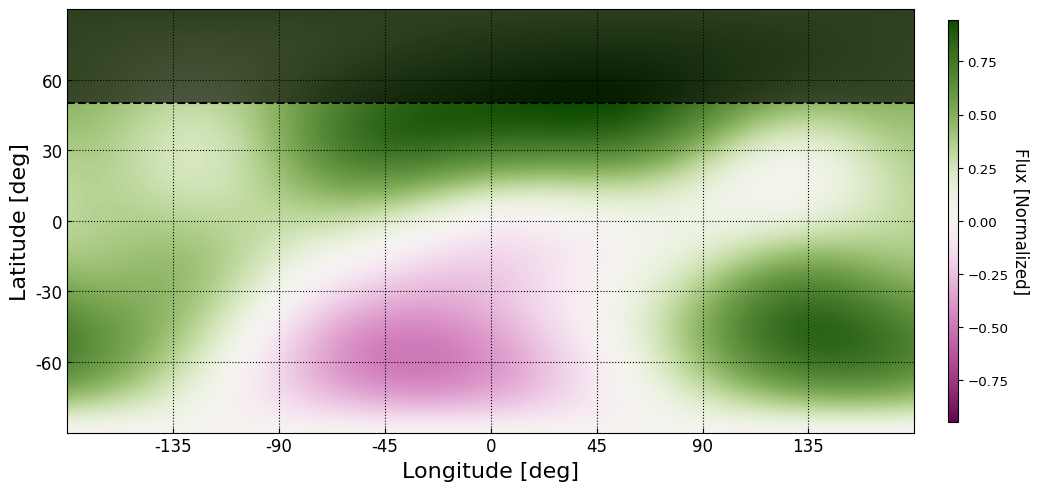

In [15]:
s1.map.inc = 130
norm = mpl.colors.CenteredNorm()
path = "../dev_materials"
create_emaps.emap_plot(s1, indiv_path=None, proj='rect', other_fname="test.png", cmap = cm.bam, 
                cmap_norm = norm, transparent=False, colorbar=True, colorbar_label = True, 
                fontsize=16, labels=True, title=False, border=True, ticks=True, gridlines=True, 
                unseen_line=True, cover_unseen=True)

In [ ]:
assert True == False

AssertionError: 

## Exploring having Negative Fluxes - June 10th, 2026

The idea of potentially keeping all maps as pos/neg flux with zero uniform contributions was brought up.  This may pose both physical restrictions on the math and makes scaling difficutl, so this section will explore the results of doing this

### TEST 1 - Non-null map RV with negative overall flux

In [ ]:
#read in data
base_eigens = np.loadtxt("../eridani-outputs/pos-pca-full-5-quad_limb-results-70i/stored-eigens/eigeny.txt")

non_null_eigen0 = base_eigens[0]
non_null_eigen8 = base_eigens[8]

non_null_star0 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
non_null_star8 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)

non_null_star0.map[:,:] = base_eigens[0]
non_null_star8.map[:,:] = base_eigens[8]

In [ ]:
create_emaps.emap_plot(non_null_star0, indiv_path=None, proj='moll', other_fname=None)

In [ ]:
non_null_star0.map.show(theta=145,colorbar=True,rv=False)

In [ ]:
non_null_star0.map.show(theta=145,colorbar=True,norm=mpl.colors.CenteredNorm())

In [ ]:
plt.plot(non_null_star0.map.rv(theta=np.linspace(0, 360, 361)).eval())
plt.ylim(-10000,10000)

print(np.max(non_null_star0.map.rv(theta=np.linspace(0, 360, 361)).eval()))
np.argmax(non_null_star0.map.rv(theta=np.linspace(0, 360, 361)).eval())

In [ ]:
#Confirm they are not in null space
create_rv.flux_rv_line(non_null_star0,theta = np.linspace(-180, 180, 361), flux_only=False,rv_only=False)

In [ ]:
create_rv.map_animations(non_null_star0,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False, norm=mpl.colors.CenteredNorm())

In [ ]:
non_null_star0.map[0,0] = 0

create_rv.map_animations(non_null_star0,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False, norm=mpl.colors.CenteredNorm())

In [ ]:
create_emaps.emap_plot(non_null_star8, indiv_path=None, proj='moll', other_fname=None)

In [ ]:
non_null_star8.map.show(theta=0,colorbar=True,norm=mpl.colors.CenteredNorm())

In [ ]:
create_rv.flux_rv_line(non_null_star8,theta = np.linspace(-180, 180, 361), flux_only=False,rv_only=False)

In [ ]:
create_rv.map_animations(non_null_star8,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False, norm=mpl.colors.CenteredNorm())

In [ ]:
non_null_star8.map[0,0] = 0

create_rv.map_animations(non_null_star8,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False, norm=mpl.colors.CenteredNorm())

### TEST 2-Removing Negative from Non-Null

In [ ]:
print(non_null_star0.map.y.eval())

In [ ]:
non_null_star0.map[0,0] = 2

create_rv.map_animations(non_null_star0,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

In [ ]:
non_null_star8.map[0,0] = 2

create_rv.map_animations(non_null_star8,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

### TEST 3 - Null maps with Negative Surface Values

In [ ]:
#read in data
base_eigens = np.loadtxt("../eridani-outputs/pos-pca-full-5-quad_limb-results-70i/stored-eigens/eigeny.txt")

non_null_eigen14 = base_eigens[14]
non_null_eigen30 = base_eigens[30]

non_null_star14 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
non_null_star30 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)

non_null_star14.map[:,:] = non_null_eigen14
non_null_star30.map[:,:] = non_null_eigen30

In [ ]:
create_emaps.emap_plot(non_null_star14, indiv_path=None, proj='moll', other_fname=None)

In [ ]:
create_rv.flux_rv_line(non_null_star14,theta = np.linspace(-180, 180, 361), flux_only=False,rv_only=False)

In [ ]:
create_rv.map_animations(non_null_star14,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

In [ ]:
non_null_star14.map[0,0] = 3

create_rv.map_animations(non_null_star14,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

In [ ]:
create_emaps.emap_plot(non_null_star30, indiv_path=None, proj='moll', other_fname=None)

In [ ]:
create_rv.flux_rv_line(non_null_star30,theta = np.linspace(-180, 180, 361), flux_only=False,rv_only=False)

In [ ]:
create_rv.map_animations(non_null_star30,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

In [ ]:
non_null_star30.map[0,0] = 3

create_rv.map_animations(non_null_star30,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

### TEST 4 - What if Flux integrates to a negative?

In [ ]:
non_null_star30.map[0,0] = 1
create_emaps.emap_plot(non_null_star30, indiv_path=None, proj='moll', other_fname=None)

In [ ]:
non_null_star30.map[0,0] = -1
create_emaps.emap_plot(non_null_star30, indiv_path=None, proj='moll', other_fname=None)

In [ ]:
create_rv.flux_rv_line(non_null_star30,theta = np.linspace(-180, 180, 361), flux_only=False,rv_only=False)

In [ ]:
create_rv.map_animations(non_null_star30,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

In [ ]:
non_null_star30.map[0,0] = -3

create_rv.map_animations(non_null_star30,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

### TEST 5 - Normalized null maps to zero flux

In [ ]:
#read in data
base_eigens = np.loadtxt("../eridani-outputs/pos-pca-full-5-quad_limb-results-70i/stored-norm-null-eigens/norm_null_eigeny.txt")

norm_null10 = base_eigens[10]
norm_null20 = base_eigens[20]

norm_null_star10 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
norm_null_star20 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)

norm_null_star10.map[:,:] = norm_null10
norm_null_star20.map[:,:] = norm_null20

In [ ]:
create_emaps.emap_plot(norm_null_star10, indiv_path=None, proj='moll', other_fname=None)
create_emaps.emap_plot(norm_null_star20, indiv_path=None, proj='moll', other_fname=None)

In [ ]:
# norm_null_star10.map.flux(theta = np.linspace(-180, 180, 361)).eval()
#norm_null_star20.map.flux(theta = np.linspace(-180, 180, 361)).eval()

In [ ]:
create_rv.flux_rv_line(norm_null_star10,theta = np.linspace(-180, 180, 361), flux_only=False,rv_only=False)
create_rv.flux_rv_line(norm_null_star20,theta = np.linspace(-180, 180, 361), flux_only=False,rv_only=False)

In [ ]:
create_rv.map_animations(norm_null_star10,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

### TEST 6 - Realistic Null's with uniform removed in post

In [ ]:
#read in data
base_eigens = np.loadtxt("../eridani-outputs/pos-pca-full-5-quad_limb-results-70i/stored-norm-null-eigens/norm_null_eigeny.txt")

norm_null10 = base_eigens[10]
norm_null20 = base_eigens[20]

In [ ]:
realistic_star, inv_realistic_star, uni_star_limb, uni_star, ratio_no_limb = create_real_null.set_up_stars(fit, norm_null10)

In [ ]:
realistic_star, inv_realistic_star, uni_star_limb, adj_uni_comp, ratio_below, ratio_above, uni_value = \
            create_real_null.set_up_real_map(realistic_star, inv_realistic_star, uni_star_limb, ratio_no_limb,interval=.2)

In [ ]:
create_real_null.scale_real_map(realistic_star, uni_star_limb, 
                        scale_value=1, uni_comp=adj_uni_comp, 
                        ratio_no_limb=ratio_no_limb)

In [ ]:
uni_star_limb.map.amp /= ratio_no_limb
print(np.unique(uni_star_limb.map.render(rv=False,projection="rect").eval()))
uni_star_limb.map.amp *= ratio_no_limb
print(np.max(uni_star_limb.map.intensity(rv=False,projection="rect",lat=0,lon=np.linspace(-90,90,91)).eval()))

In [ ]:
realistic_star.map.amp /= ratio_no_limb
create_emaps.emap_plot(realistic_star, indiv_path=None, proj='moll', other_fname=None,cmap=cm.buda,center_flux=0.3873)
realistic_star.map.amp *= ratio_no_limb

In [ ]:
create_rv.map_animations(realistic_star,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

In [ ]:
create_rv.map_animations(uni_star_limb,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

In [ ]:
realistic_star.map[0,0] += 10
create_rv.map_animations(realistic_star,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)
realistic_star.map[0,0] -= 10

In [ ]:
previous_uni = realistic_star.map[0,0].eval()
print(previous_uni)

In [ ]:
realistic_star.map[0,0] -= previous_uni

realistic_star.map.amp /= ratio_no_limb
create_emaps.emap_plot(realistic_star, indiv_path=None, proj='moll', other_fname=None,cmap=cm.buda,center_flux=0)
realistic_star.map.amp *= ratio_no_limb

create_rv.map_animations(realistic_star,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)
realistic_star.map[0,0] += previous_uni

In [ ]:
norm_null10[0]

In [ ]:
realistic_star.map[0,0] = norm_null10[0]

realistic_star.map.amp /= ratio_no_limb
create_emaps.emap_plot(realistic_star, indiv_path=None, proj='moll', other_fname=None,cmap=cm.buda
                       ,center_flux=0)
realistic_star.map.amp *= ratio_no_limb

create_rv.map_animations(realistic_star,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)
realistic_star.map[0,0] = previous_uni

In [ ]:
realistic_star.map[0,0] = norm_null10[0]
realistic_star.map.amp /= ratio_no_limb
print(np.nanmax(realistic_star.map.render().eval()))
realistic_star.map.show(colorbar=True)
realistic_star.map.amp *= ratio_no_limb
realistic_star.map[0,0] = previous_uni

In [ ]:
realistic_star.map[0,0] = norm_null10[0]
realistic_star.map.amp += 10

realistic_star.map.amp /= ratio_no_limb
create_emaps.emap_plot(realistic_star, indiv_path=None, proj='moll', other_fname=None,cmap=cm.buda
                       ,center_flux=0)
realistic_star.map.amp *= ratio_no_limb

create_rv.map_animations(realistic_star,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)
realistic_star.map[0,0] = previous_uni
realistic_star.map.amp -= 10

In [ ]:
realistic_star.map[0,0] = norm_null10[0]
realistic_star.map[1:,:] *= 10

realistic_star.map.amp /= ratio_no_limb
create_emaps.emap_plot(realistic_star, indiv_path=None, proj='moll', other_fname=None,cmap=cm.buda
                       ,center_flux=0)
realistic_star.map.amp *= ratio_no_limb

create_rv.map_animations(realistic_star,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)
realistic_star.map[0,0] = previous_uni
realistic_star.map[1:,:] /= 10